# **Data Understanding**

## Mencari Outlier dengan Metode ABOD

In [ ]:
!pip install pyod


🔹 Data Awal:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

🔹 Data dengan label outlier:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species  Outlier  Outlier_Score
9     10            4.9           3.1            1.5           0.1      Iris-setosa        1      -0.000000
15    16            5.7           4.4            1.5           0.4      Iris-setosa        1      -0.151208
22    23            4.6           3.6            1.0           0.2      Iris-setosa        1      -0.526933
34    35            4.9           3.1            1.5           

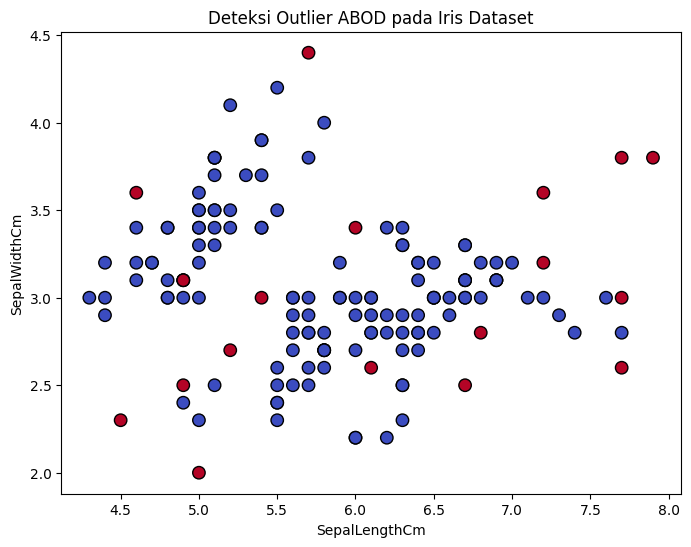

In [17]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
from pyod.models.abod import ABOD
from sklearn.preprocessing import StandardScaler

# Baca dataset
df = pd.read_csv("Iris (1).csv")
print("🔹 Data Awal:")
print(df.head())

# hapus kolom Id dan Species karena bukan termasuk numerik
X = df.drop(columns=['Id', 'Species'])

# Normalisasi data agar skala sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inisialisasi ABOD dengan contamination (asumsi outlier yang diinginkan)
abod = ABOD(contamination=0.1)  # 10% diasumsikan outlier
abod.fit(X_scaled)

# Prediksi outlier
df['Outlier'] = abod.predict(X_scaled)        # 0 = normal, 1 = outlier
df['Outlier_Score'] = abod.decision_function(X_scaled)

print("\n🔹 Data dengan label outlier:")
print(df[df['Outlier'] == 1].to_string())


# Statistik jumlah outlier per kelas
print("\n🔹 Jumlah outlier per species:")
print(df.groupby('Species')['Outlier'].sum())

# Visualisasi (contoh: SepalLengthCm vs SepalWidthCm)
plt.figure(figsize=(8,6))
plt.scatter(df['SepalLengthCm'], df['SepalWidthCm'],
            c=df['Outlier'], cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")
plt.title("Deteksi Outlier ABOD pada Iris Dataset")
plt.show()

## Mencari Outlier dengan Metode K-Nearest Neighbors (KNN)

🔹 Data Awal:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

🔹 Data dengan label outlier:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species  Outlier  Outlier_Score
15    16            5.7           4.4            1.5           0.4      Iris-setosa        1       1.218094
41    42            4.5           2.3            1.3           0.3      Iris-setosa        1       1.629658
60    61            5.0           2.0            3.5           1.0  Iris-versicolor        1       1.112085
85    86            6.0           3.4            4.5           

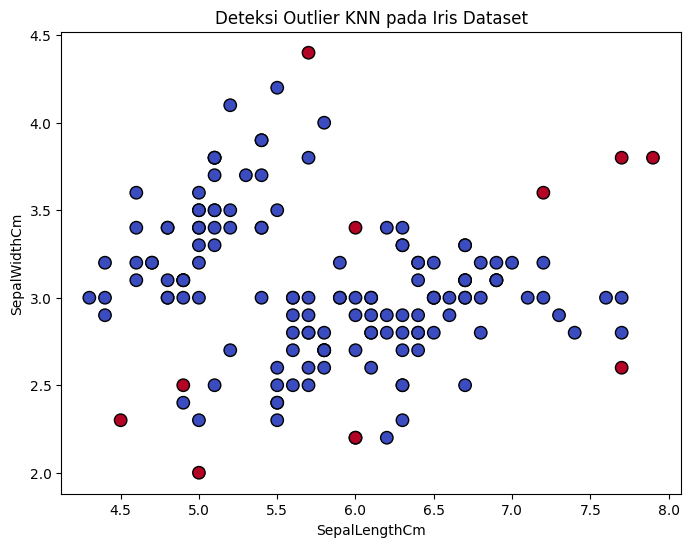

In [18]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
from pyod.models.knn import KNN
from sklearn.preprocessing import StandardScaler

# Baca dataset
df = pd.read_csv("Iris (1).csv")
print("🔹 Data Awal:")
print(df.head())

# Pilih fitur numerik (hapus kolom Id dan Species)
X = df.drop(columns=['Id', 'Species'])

# Normalisasi data agar skala sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inisialisasi KNN
knn_model = KNN(contamination=0.1)  # 10% diasumsikan outlier
knn_model.fit(X_scaled)

# Prediksi outlier
df['Outlier'] = knn_model.predict(X_scaled)        # 0 = normal, 1 = outlier
df['Outlier_Score'] = knn_model.decision_function(X_scaled)

print("\n🔹 Data dengan label outlier:")
print(df[df['Outlier'] == 1].to_string())

# Statistik jumlah outlier per kelas
print("\n🔹 Jumlah outlier per species:")
print(df.groupby('Species')['Outlier'].sum())

# Visualisasi (SepalLengthCm vs SepalWidthCm)
plt.figure(figsize=(8,6))
plt.scatter(df['SepalLengthCm'], df['SepalWidthCm'],
            c=df['Outlier'], cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")
plt.title("Deteksi Outlier KNN pada Iris Dataset")
plt.show()


## Mencari Outlier dengan Metode Local Outlier Factor (LOF)

🔹 Data Awal:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

🔹 Data dengan label outlier:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species  Outlier  Outlier_Score
15    16            5.7           4.4            1.5           0.4     Iris-setosa        1       1.958087
33    34            5.5           4.2            1.4           0.2     Iris-setosa        1       1.573389
41    42            4.5           2.3            1.3           0.3     Iris-setosa        1       1.891710
117  118            7.7           3.8            6.7           2.2 

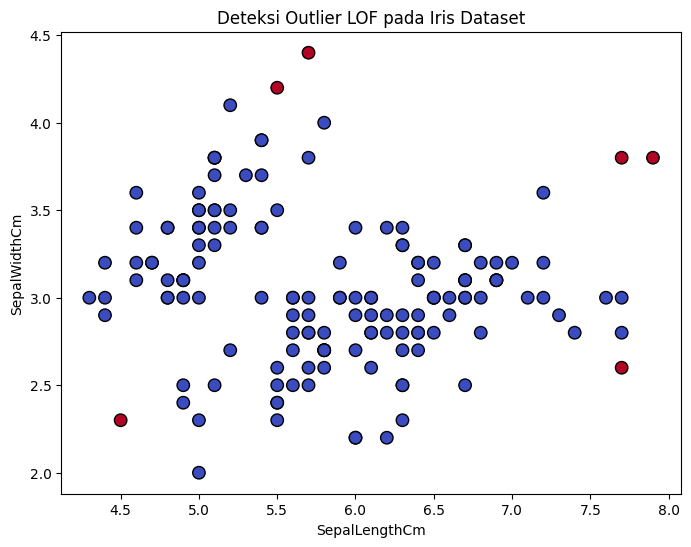

In [19]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
from pyod.models.lof import LOF
from sklearn.preprocessing import StandardScaler

# Baca dataset
df = pd.read_csv("Iris (1).csv")
print("🔹 Data Awal:")
print(df.head())

# Pilih fitur numerik (hapus kolom Id dan Species)
X = df.drop(columns=['Id', 'Species'])

# Normalisasi data agar skala sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inisialisasi LOF
lof_model = LOF(contamination=0.05, n_neighbors=20)  # 5% diasumsikan outlier
lof_model.fit(X_scaled)

# Prediksi outlier
df['Outlier'] = lof_model.predict(X_scaled)        # 0 = normal, 1 = outlier
df['Outlier_Score'] = lof_model.decision_function(X_scaled)

print("\n🔹 Data dengan label outlier:")
print(df[df['Outlier'] == 1].to_string())

# Statistik jumlah outlier per kelas
print("\n🔹 Jumlah outlier per species:")
print(df.groupby('Species')['Outlier'].sum())

# Visualisasi (SepalLengthCm vs SepalWidthCm)
plt.figure(figsize=(8,6))
plt.scatter(df['SepalLengthCm'], df['SepalWidthCm'],
            c=df['Outlier'], cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")
plt.title("Deteksi Outlier LOF pada Iris Dataset")
plt.show()
